In [4]:
from jax import config
config.update("jax_enable_x64", True)
from pathlib import Path
import glob 

In [5]:
import matplotlib.pyplot as plt 
from spectres import spectres
import numpy as np
import jax.numpy as jnp 
import pickle 
import pandas as pd 
import numpy as np
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


In [6]:
from sheap import Sheapectral
from sheap.Utils.SpectralReaders import parallel_reader 

from sheap.Utils.Paper import plot_logdex_agreement,posterior_extraction,plot_ratio_histogram,compare_from_data_dict,extract_data,_apply_transform,compare_res,bins_centered_on_zero,summary_similarity
from sheap.SheaProducts.Utils.MoldelSpectraReconstruction import MoldelSpectraReconstruction

In [7]:
# _=plot_logdex_agreement_v3(data_dict,lims=[2.8,4.5],ref_label="Wu&Shen22",label_mode="FWHM",add_numbers=False,colors=(
#         "#db3333", "#2ca02c", "#d62728",
#         "#6b67bd", "#8c564b", "#e377c2", "#7f7f7f"),sn=sheapspectral.snr,save_file="images/fwhm_compare_wushen22.pdf",label_colorbar="S/N")#)

In [8]:
#

In [9]:
%load_ext autoreload
%autoreload 2

In [10]:
base_panda = pd.read_csv("../pickle_spectra/DESI_spec.csv")

In [11]:
base_panda.shape

(500, 29)

In [12]:
sheapspectral = Sheapectral.from_pickle("Pan25_montecarlo_rachi.pkl")

In [17]:
df_extra = posterior_extraction(
	 sheapspectral,
	 posterior_idx=1,
	 extra_key="extra_params",
 )


/share/cav/data/favila/smbh_mass/sheap/sheap/Utils/Paper.py:159: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [19]:
df_extra[df_extra["SMBHEstimator"]=="MR16_global_MgII_L3000_FWHM"]

,n_obj,name,line,SMBHEstimator,quantity,method,wavelength,vwidth_def,combined,median,err_minus,err_plus,low_q,high_q,nsamp
21,0,39628018812982379,MgII,MR16_global_MgII_L3000_FWHM,vwidth_kms,continuum,3000,fwhm,False,3.246981e+03,8.804900e+01,7.715012e+01,0.16,0.84,50
22,0,39628018812982379,MgII,MR16_global_MgII_L3000_FWHM,log10_smbh,continuum,3000,fwhm,False,8.916808e+00,2.398517e-02,2.103562e-02,0.16,0.84,50
23,0,39628018812982379,MgII,MR16_global_MgII_L3000_FWHM,Lwave,continuum,3000,fwhm,False,3.690826e+45,1.430554e+43,1.186641e+43,0.16,0.84,50
24,0,39628018812982379,MgII,MR16_global_MgII_L3000_FWHM,Lbol,continuum,3000,fwhm,False,1.900775e+46,7.367352e+43,6.111201e+43,0.16,0.84,50
25,0,39628018812982379,MgII,MR16_global_MgII_L3000_FWHM,Ledd,continuum,3000,fwhm,False,1.040348e+47,5.589441e+45,5.163103e+45,0.16,0.84,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20981,499,39633227643618250,MgII,MR16_global_MgII_L3000_FWHM,Lwave,continuum,3000,fwhm,False,1.844525e+45,1.182772e+43,1.987449e+43,0.16,0.84,50
20982,499,39633227643618250,MgII,MR16_global_MgII_L3000_FWHM,Lbol,continuum,3000,fwhm,False,9.499303e+45,6.091274e+43,1.023536e+44,0.16,0.84,50
20983,499,39633227643618250,MgII,MR16_global_MgII_L3000_FWHM,Ledd,continuum,3000,fwhm,False,1.553278e+47,1.070128e+46,1.165673e+46,0.16,0.84,50
20984,499,39633227643618250,MgII,MR16_global_MgII_L3000_FWHM,mdot_msun_per_year,continuum,3000,fwhm,False,1.677395e+00,1.075602e-02,1.807369e-02,0.16,0.84,50


In [20]:
mask = (
	(df_extra["line"] == "MgII") &
	(df_extra["SMBHEstimator"] == "MR16_global_MgII_L3000_FWHM") &
	(df_extra["quantity"] == "vwidth_kms")
)

MgII_FWHM_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
MgII_FWHM_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
MgII_FWHM_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

mask = (
	(df_extra["line"] == "MgII") &
	(df_extra["SMBHEstimator"] == "MR16_global_MgII_L3000_FWHM") &
	(df_extra["quantity"] == "Lwave")
)

L3000_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
L3000_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
L3000_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

In [21]:
MGII_FWHM_DAS_median = base_panda.FWHM_DAS.values
MGII_FWHM_DAS_ERR = base_panda.FWHM_DAS_ERR.values
MgII_FSF = base_panda.FWHM_FSF.values

L3000_DAS_median,L3000_DAS_ERR,L3000_DAS_ERR = 1e44 *base_panda.L3000_DAS.values,1e44 *base_panda.L3000_DAS_ERR.values,1e44 *base_panda.L3000_DAS_ERR.values
L3000_FSF = 1e44 * base_panda.L3000_FSF.values

In [23]:
base_panda.columns

Index(['RA', 'DEC', 'TARGETID', 'PROGRAM', 'HEALPIX', 'REDSHIFT', 'RMAG',
       'EW_DAS', 'EW_DAS_ERR', 'FWHM_DAS', 'FWHM_DAS_ERR', 'RFE_DAS',
       'RFE_DAS_ERR', 'L3000_DAS', 'L3000_DAS_ERR', 'LOGMASS_DAS_PAN25',
       'LOGMASS_DAS_PAN25_ERR', 'LOGMASS_DAS_VO09', 'LOGMASS_DAS_VO09_ERR',
       'LOGMASS_DAS_SHEN11', 'LOGMASS_DAS_SHEN11_ERR', 'LOGMASS_DAS_LE20',
       'LOGMASS_DAS_LE20_ERR', 'LOGMASS_DAS_YU23', 'LOGMASS_DAS_YU23_ERR',
       'L3000_FSF', 'FWHM_FSF', 'LOGMASS_FSF_VO09', 'path'],
      dtype='object')

Bad errors minus in index [ 11  88 150 183 295 315 370 399 430 433 436 463 499] 100% error


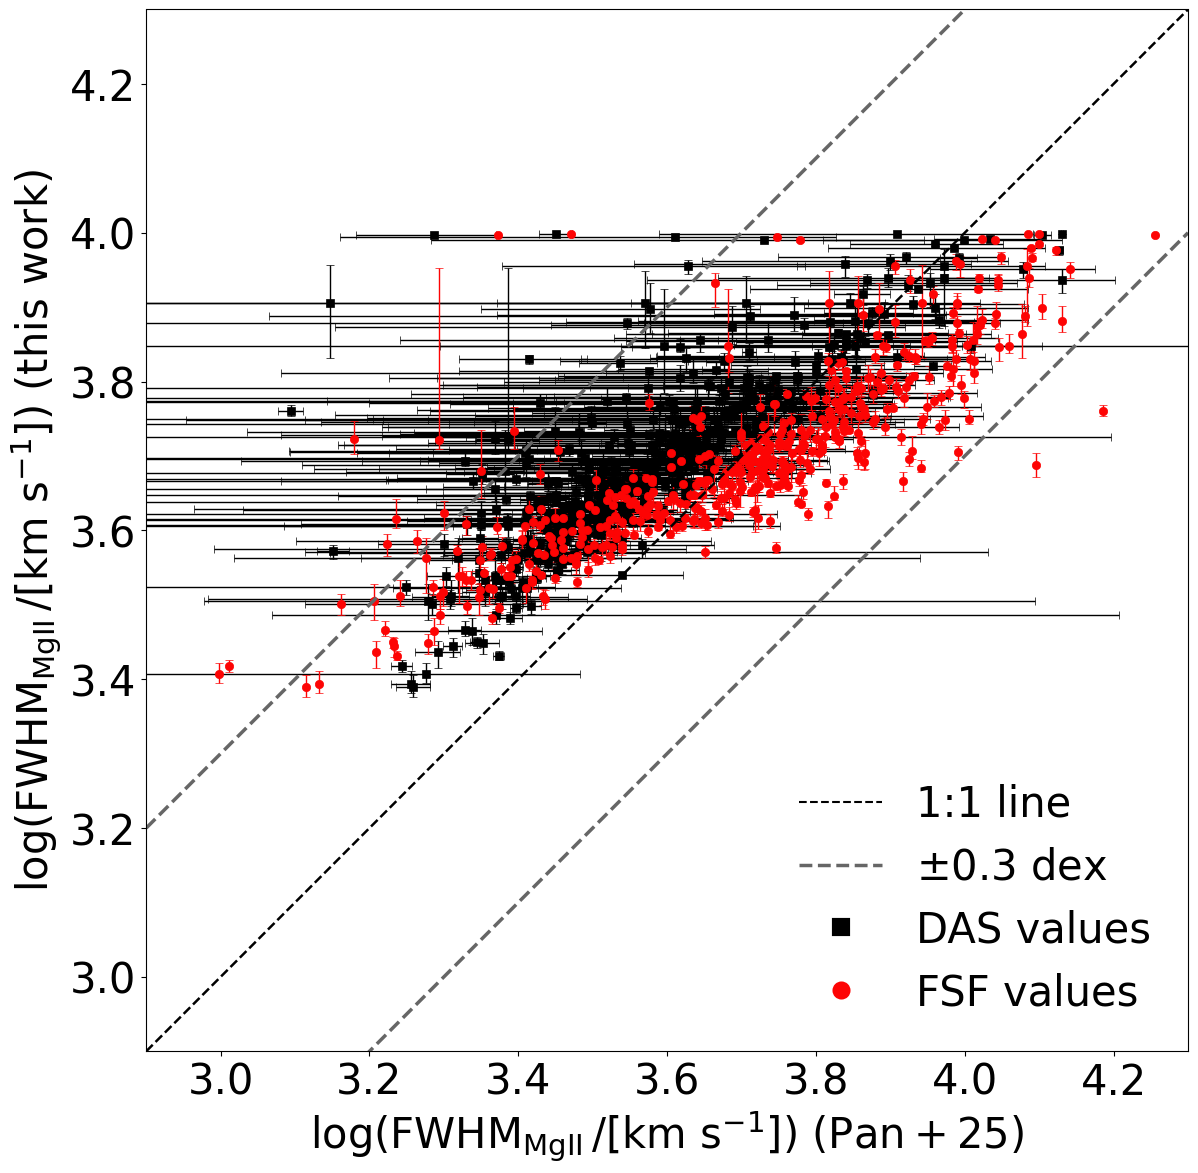

In [37]:
data_dict = {
	r"DAS values": {
		"x": np.vstack([MGII_FWHM_DAS_median,MGII_FWHM_DAS_ERR]),          # (2, N) symmetric error
		"y": np.vstack([MgII_FWHM_median,MgII_FWHM_err_plus,MgII_FWHM_err_minus]),  # (3, N) +/-
	},
	r"FSF values": {
		"x": np.vstack([MgII_FSF]),          # (2, N) symmetric error
		"y": np.vstack([MgII_FWHM_median,MgII_FWHM_err_plus,MgII_FWHM_err_minus]),  # (3, N) +/-
	},}
text = None#{"text":"MgII FWHM","ypos":0.95}
save_file ="images/fwhm_compare_PAN25.pdf"
sn = None#sheapspectral.snr
(_,_,FWHM,_) = plot_logdex_agreement(data_dict,lims=[2.9,4.3],
							 ref_label="MgII",label_mode="fwhm_clasic",ref_work="Pan+25",add_numbers=False,colors=("#000000", "#fd0404f8"),
							 text=text,sn=sn,save_file=save_file,label_colorbar="S/N",markers= ('s','o'))#)

In [40]:
z = sheapspectral.z
_z, _efunc, _comoving_radial_distance = np.loadtxt("desi_fiducial_cosmology.dat", comments='#', usecols=None, unpack=True)
z = np.asarray(z)
mask = (z < _z[0]) | (z > _z[-1])
if mask.any():
	raise ValueError('Input z outside of tabulated range.')
jeje = np.interp(z, _z, _comoving_radial_distance, left=None, right=None)
from sheap.Utils.Constants import cm_per_mpc
#dFSF [Mpc/h]
dFSF = jeje * (1. + z) * cm_per_mpc


In [41]:
#[Mpc/h]

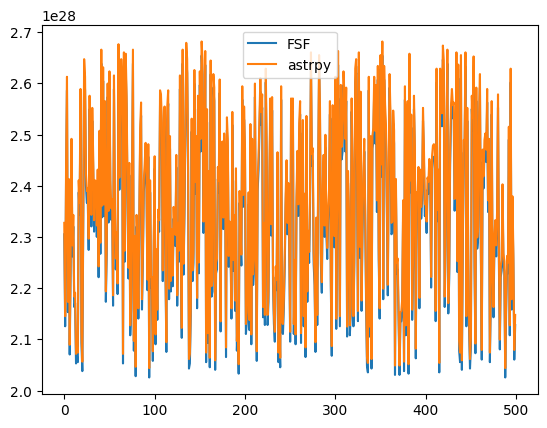

In [42]:
plt.plot((dFSF/0.7),label="FSF")
plt.plot(sheapspectral._calcualte_d(H0=70),label="astrpy")
plt.legend()

In [43]:
# sheapspectral._calcualte_d(H0=70)

In [44]:
d_L3000_FSF = (L3000_FSF) * ((sheapspectral._calcualte_d())/ (dFSF/1.0))**2 #/(1+sheapspectral.z) #*1.2

In [45]:
delta = L3000_median - L3000_FSF
offset = np.median(delta)   # or mean
scatter = np.std(delta, ddof=1)

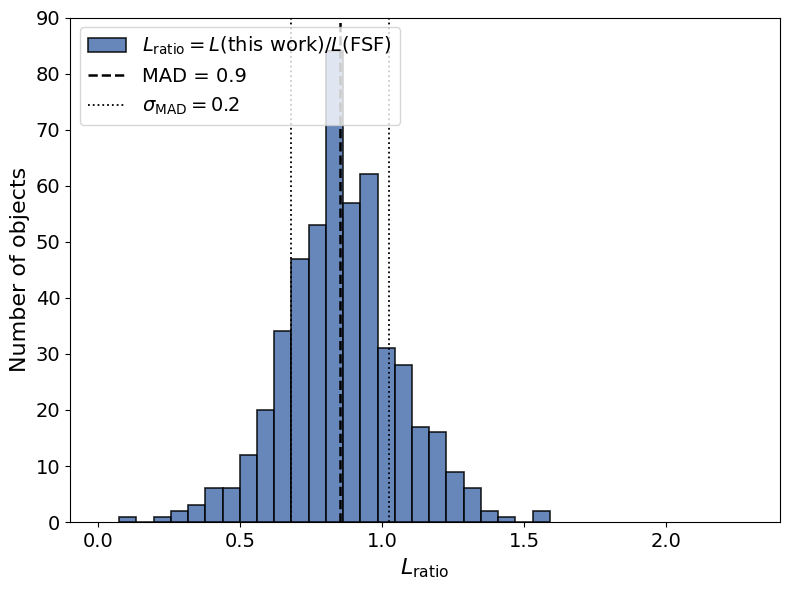

In [46]:
ratio = L3000_median / d_L3000_FSF

fig, ax = plot_ratio_histogram(
	ratio,
	bins=25,
	figsize=(8, 6),
	color="#4C72B0",
	edgecolor="black",
	alpha=0.85,
	label=r"$L_{\mathrm{ratio}} = L(\mathrm{this\ work}) / L(\mathrm{FSF})$",
	xlabel=r"$L_{\mathrm{ratio}}$",
	add_median_value=True,
	legend_loc='upper left',
	ylim=[0,90],
	xlim=[-0.1,2.4]
)


In [47]:
# (2.0 * np.sqrt(2.0 * np.log(2.0))),np.sqrt(2.0 * np.pi) 

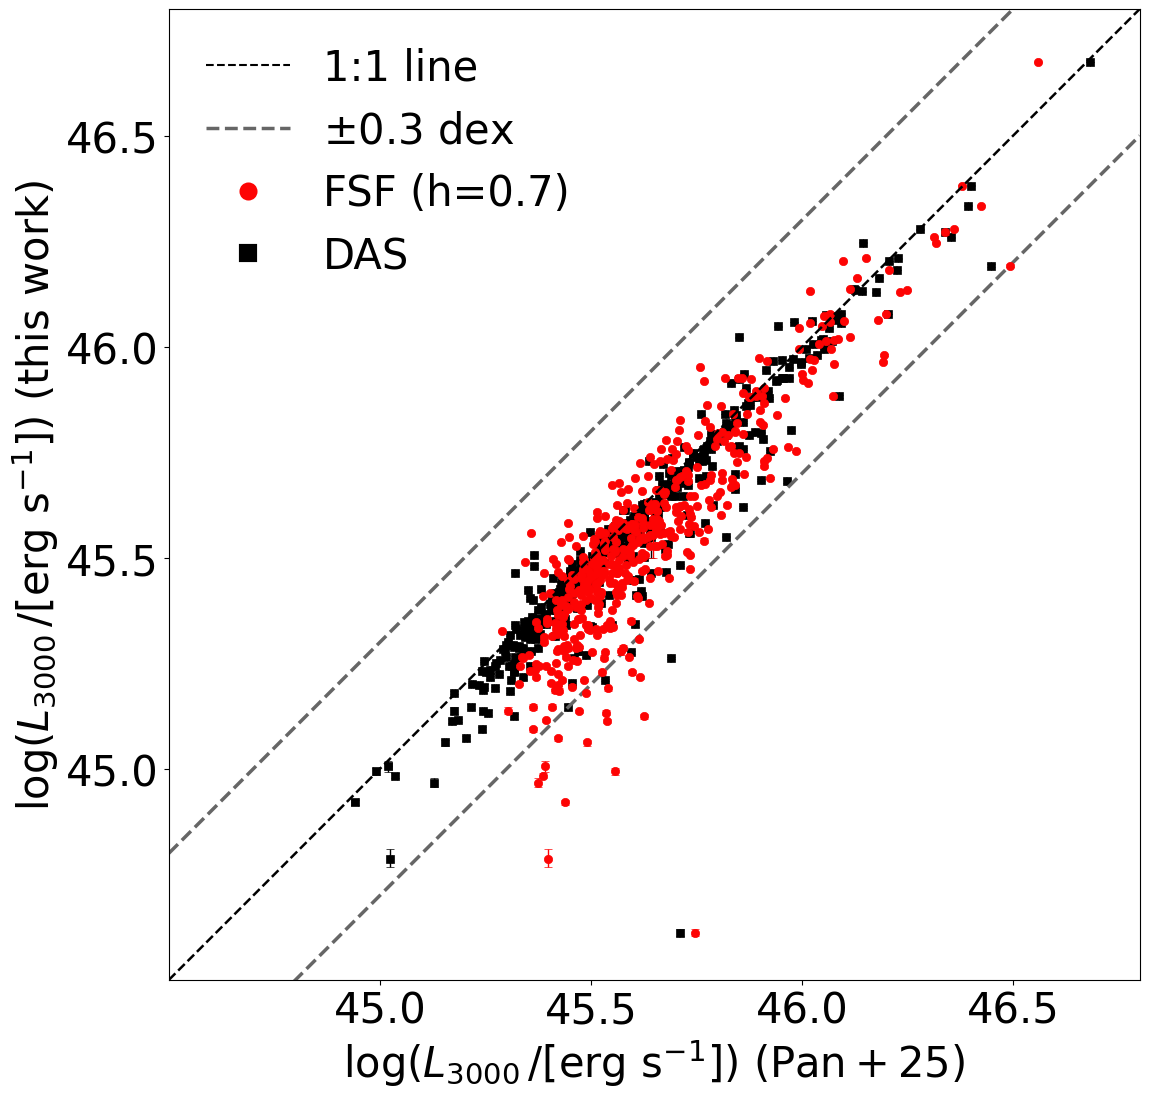

In [48]:
data_dict = {
	r"FSF (h=0.7)": {
		"x": np.vstack([(d_L3000_FSF)]),
		"y": np.vstack([L3000_median,L3000_err_plus,L3000_err_minus]),  # (3, N) +/-
	"zorder":2},
	 "DAS": {
		"x": np.vstack([L3000_DAS_median,L3000_DAS_ERR]), 
		"y": np.vstack([L3000_median,L3000_err_plus,L3000_err_minus]),  # (3, N) +/-
	},
	}
text = None#{"text":r"$\lambda L_{\lambda}(3000\,\AA)$","xpos":0.8,"ypos":0.3}
save_file ="images/l3000_compare_PAN25_cosmo.pdf"
sn =None#sheapspectral.snr
(_,_,continuum_stuf,_) = plot_logdex_agreement(data_dict,lims=[44.5,46.8],ref_label="3000",label_mode="l_clasic",ref_work="Pan+25"
										  ,add_numbers=False,colors=( "#fd0404f8","#000000"),save_file=save_file,legend_loc="upper left",sn=sn,label_colorbar="S/N"
										  ,ref_wavelenght=3000,text=text)

In [49]:
# sheapspectral.result.region_list

In [50]:
from sheap.Assistants.parser_mapper import get_multiple_sample_params,get_sample_params,summarize_spectral_lines

In [51]:
summary = summarize_spectral_lines(sheapspectral.result.region_list)

=== SpectralLine summary ===
Counts by region:
  - balmer: 2
  - broad: 1
  - continuum: 1
  - fe: 1

Gaussian-ish entries (profile/subprofile contains 'gaussian'): 1
Gaussian-ish by region:
  - broad: 1

Continuum components:
  - continuum / continuum1 (profile: powerlaw)

Line mappings (region / component):
  - broad / broad1: 12 lines
      Hε - 3970.072
      Hδ - 4101.742
      HeIIb - 2733.290
      HeIa - 2945.106
      HeIb - 3187.745
      HeIIc - 3203.100
      HeIc - 4143.761
      Hg - 4340.471
      SiIII] - 1892.000
      CIII] - 1908.730
      AlIII - 1858.753
      MgII - 2799.000


In [52]:
sheapspectral.result.region_list

[SpectralLine(line_name='balmercontinuum', center=None, region='balmer', component=0, subregion=None, amplitude=None, element=None, profile='balmercontinuum', region_lines=None, amplitude_relations=None, subprofile=None, rarity=None, template_info=None),
 SpectralLine(line_name='balmerhighorder', center=None, region='balmer', component=0, subregion=None, amplitude=None, element=None, profile='template', region_lines=None, amplitude_relations=None, subprofile=None, rarity=None, template_info={'name': 'BalHiOrd', 'x_min': 1750, 'x_max': 4400}),
 SpectralLine(line_name='broad1', center=[3970.072, 4101.742, 2733.29, 2945.106, 3187.745, 3203.1, 4143.761, 4340.471, 1892, 1908.73, 1858.753, 2799], region='broad', component=1, subregion=[None, None, None, None, None, None, None, None, None, None, None, None], amplitude=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], element=['Hydrogen', 'Hydrogen', 'Helium', 'Helium', 'Helium', 'Helium', 'Helium', 'Hydrogen', 'Silicon', 'Carbon',

In [53]:
# 10**3.6

In [54]:
# # main_key = "basic_params"
# # region = "narrow"



# import numpy as np

# def get_sample_params(posterior, region, main_key, line_name, param):
# 	"""
# 	Extract a parameter for a given emission line within a region
# 	from a posterior dictionary, for all objects.

# 	Returns
# 	-------
# 	np.ndarray
# 		Array with shape (N_obj, N_samples, N_match)
# 	"""
# 	# reference object (structure check)
# 	first_key = next(iter(posterior))
# 	regions = posterior[first_key].get(main_key, {})

# 	if region not in regions:
# 		raise KeyError(
# 			f"Region '{region}' is not available. "
# 			f"Available regions: {list(regions.keys())}"
# 		)

# 	region_data = regions[region]

# 	lines = region_data.get("lines", [])
# 	if line_name not in lines:
# 		raise KeyError(
# 			f"Line '{line_name}' is not available in region '{region}'. "
# 			f"Available lines: {list(lines)}"
# 		)

# 	if param not in region_data:
# 		available_params = [k for k in region_data.keys() if k != "lines"]
# 		raise KeyError(
# 			f"Parameter '{param}' is not available in region '{region}'. "
# 			f"Available parameters: {available_params}"
# 		)

# 	# index of requested line(s)
# 	line_idx = np.where(np.asarray(lines) == line_name)[0]

# 	# collect samples for all objects
# 	param_samples = []
# 	for _, post in posterior.items():
# 		region_post = post[main_key][region]
# 		param_samples.append(
# 			np.asarray(region_post[param])[:, line_idx]
# 		)

# 	return np.stack(param_samples, axis=0)





In [55]:
posterior = sheapspectral.result.posterior["montecarlo"]["posterior_result"]
samples_flux_MgII = get_sample_params(posterior,"basic_params","broad","MgII","flux").squeeze()
ra = MoldelSpectraReconstruction(sheapspectral, jit_compile=True)
fe_out = ra.fe_integrated_flux()
fe_out_samples = fe_out["samples"]

Re_fe_sampled = fe_out_samples / samples_flux_MgII
RFE_DAS = base_panda.RFE_DAS.values
RFE_DAS_ERR = base_panda.RFE_DAS_ERR.values
p_lo, p_med, p_hi = np.percentile(Re_fe_sampled, [100 * 0.16, 50, 100 * 0.84],axis=1)
Re_fe_median,Re_fe_low,Re_fe_up = p_med, p_med - p_lo, p_hi - p_med

In [56]:
# posterior[39628018812982379]["basic_params"]["broad"].keys()

Careful: the following indices are outside the plot limits [-0.5, 0.75]: [172 230]


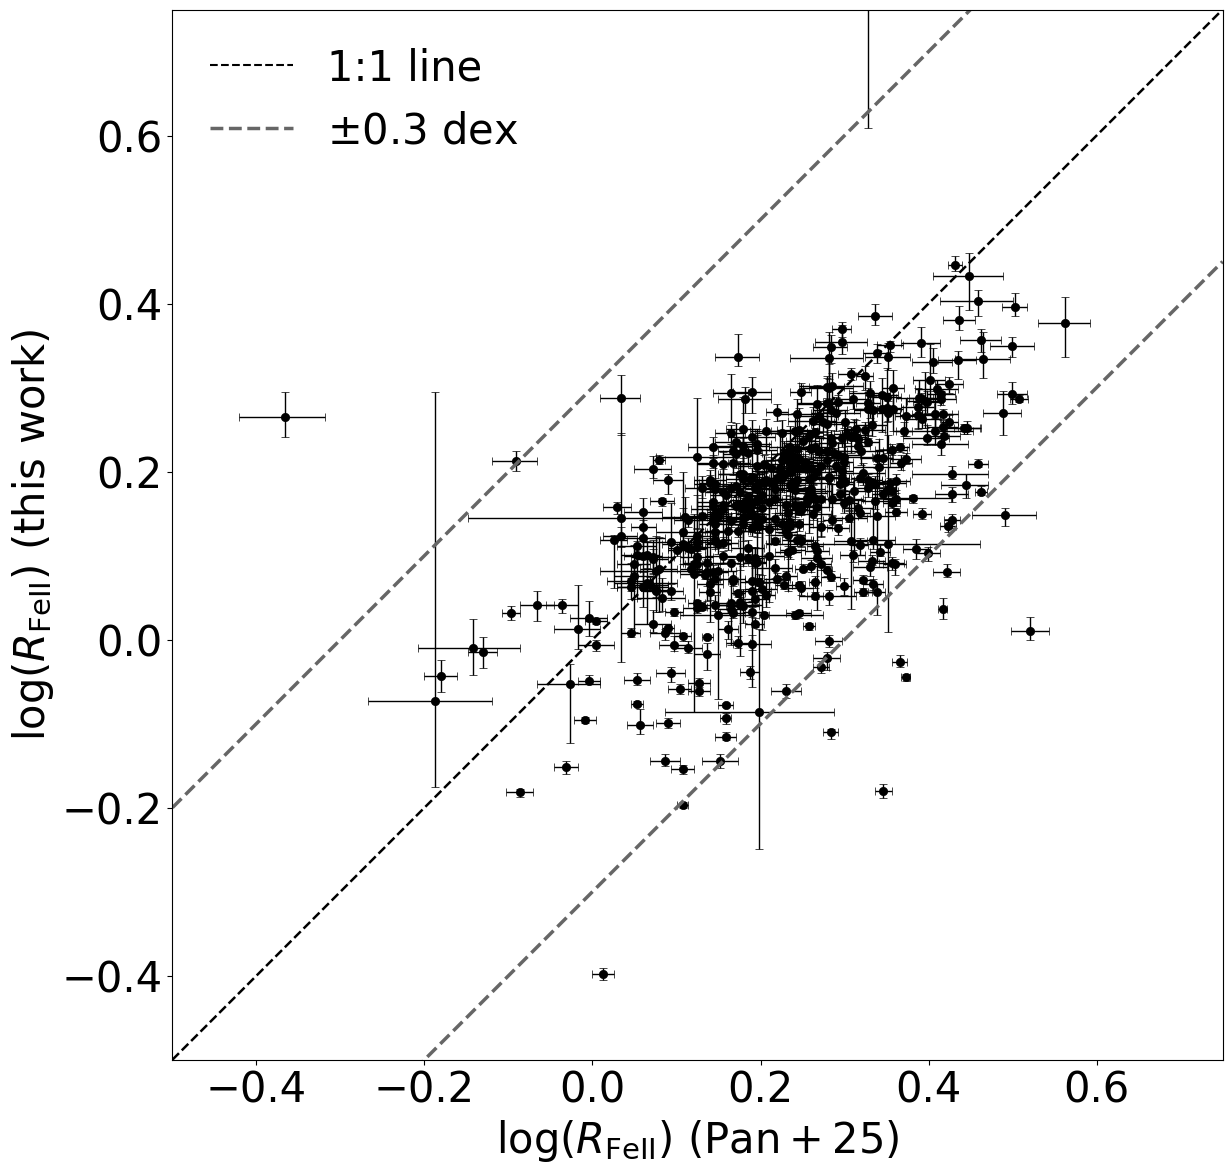

In [57]:
data_dict = {
	 "DAS values": {
		"x": np.vstack([RFE_DAS,RFE_DAS_ERR,RFE_DAS_ERR]), 
		"y": np.vstack([Re_fe_median,Re_fe_up,Re_fe_low]),  # (3, N) +/-
	},}
text = None#{"text":r"$R_{\mathrm{Fe}} = F_{\mathrm{Fe}} / F_{\mathrm{Mg\,II}}$","xpos":0.8,"ypos":0.1}
sn = None#sheapspectral.snr
(_,_,fe_s,_) = plot_logdex_agreement(data_dict,lims=[-.5,0.75],ref_label=" ",label_mode="rfe_clasic"
							 ,add_numbers=False,colors=("#000000", "#fd04046c"),legend_loc="upper left"
							 ,sn=sn,label_colorbar="S/N",ref_work="Pan+25",text=text,save_file="images/RfeII_compare_PAN25.pdf",remove_scater_legend=True)

In [58]:

# labels_p = [r"FWHM$_{\rm Mg\,II}$",r"$L_{3000}$",r"$(F_{\rm Fe\,II}/F_{\rm Mg\,II})$"]
# #compare_res(dictionaries,labels,compared_xlabel="Pan+25",save_file="images/res_distribution_pan.pdf",main_key=["DAS values","FSF values"])

In [59]:
dictionaries = [FWHM, continuum_stuf, fe_s]
for i in dictionaries:
	print(i.keys())

dict_keys(['DAS values', 'FSF values'])
dict_keys(['FSF (h=0.7)', 'DAS'])
dict_keys(['DAS values'])


FWHM$_{\rm Mg\,II}$ DAS : N=500, band=±0.300 dex, f_within=96.600, bias_med=0.115 dexNMAD=0.068 dex SHEAP larger in 30.34%
FWHM$_{\rm Mg\,II}$ FSF : N=500, band=±0.300 dex, f_within=97.000, bias_med=-0.022 dexNMAD=0.116 dex SHEAP smaller in 4.9%
$L_{3000}$ FSF (h=0.7): N=500, band=±0.300 dex, f_within=96.000, bias_med=-0.070 dexNMAD=0.088 dex SHEAP smaller in 14.93%
$L_{3000}$ DAS: N=500, band=±0.300 dex, f_within=99.200, bias_med=-0.023 dexNMAD=0.029 dex SHEAP smaller in 5.08%
$(F_{\rm Fe\,II}/F_{\rm Mg\,II})$ DAS : N=500, band=±0.300 dex, f_within=96.800, bias_med=-0.066 dexNMAD=0.095 dex SHEAP smaller in 14.15%


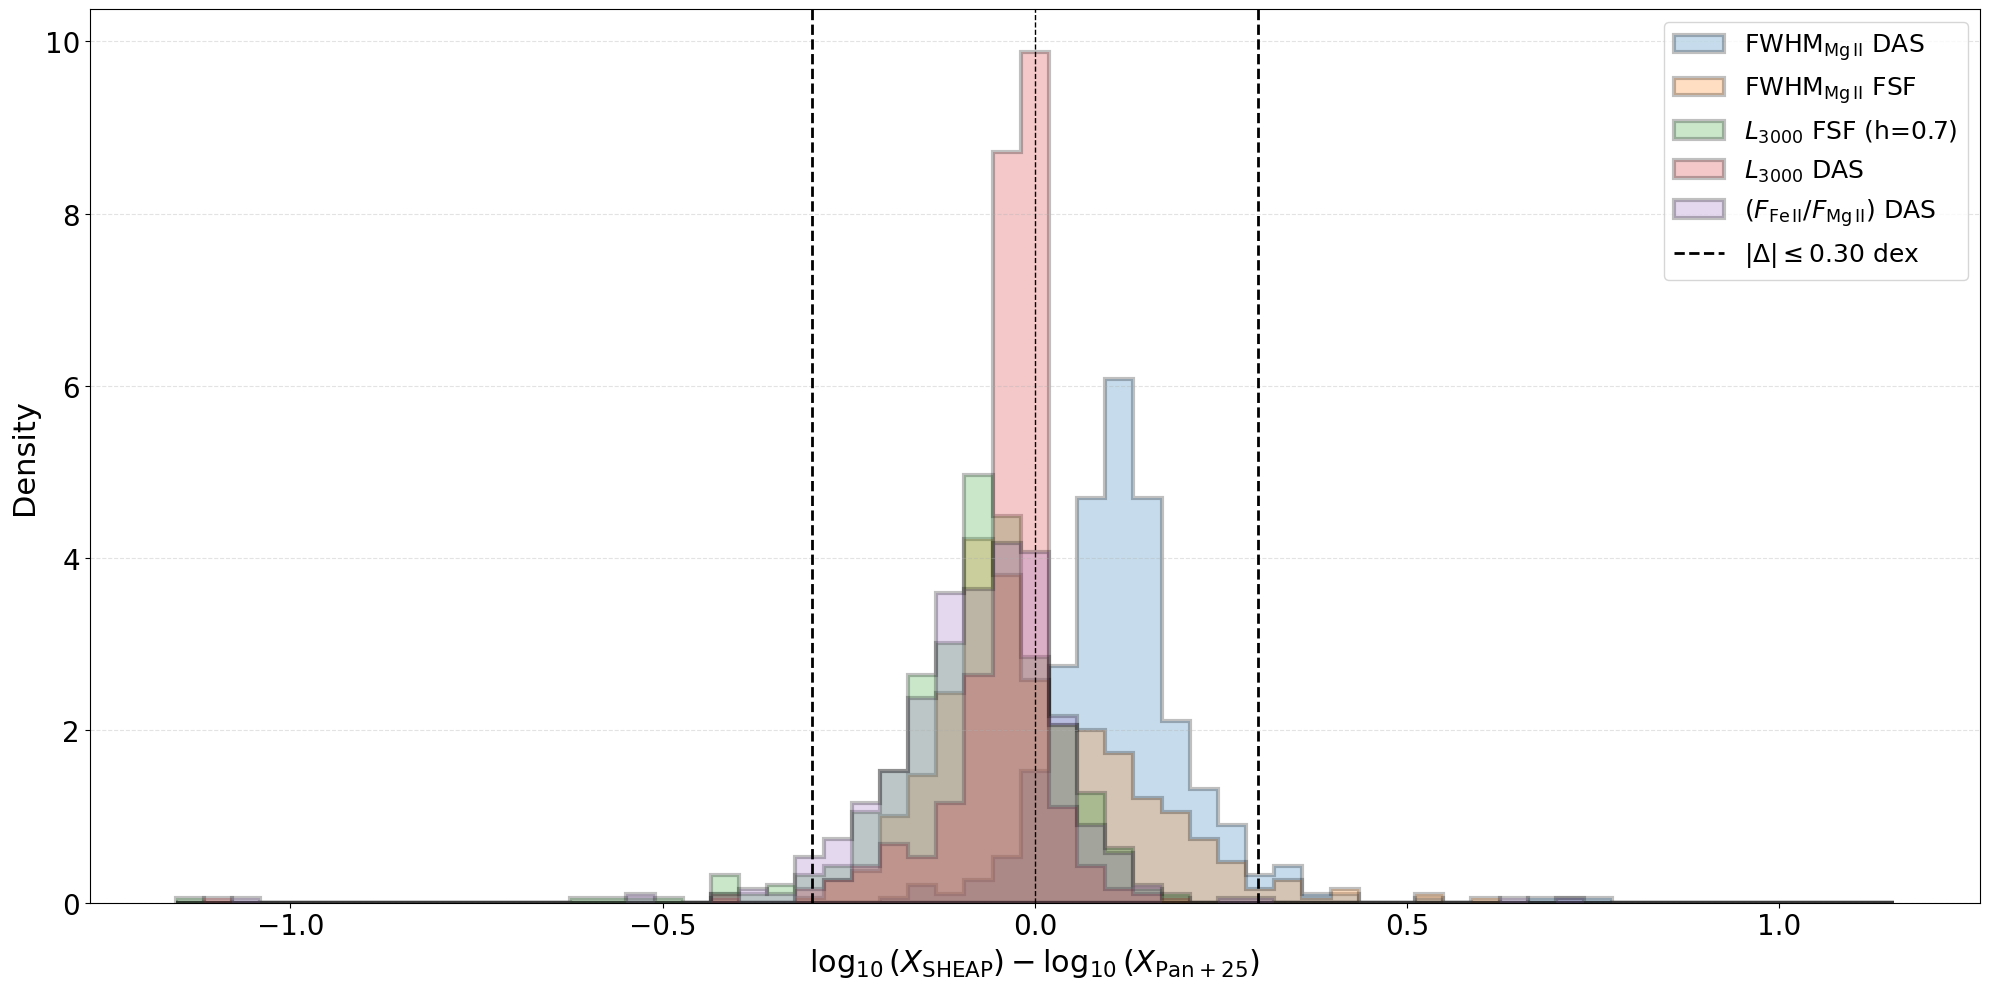

In [60]:
from matplotlib.lines import Line2D
FS = 22          # <- change this to scale everything
TICK_FS = FS - 2
LEGEND_FS = FS - 4
TITLE_FS = FS + 2

labels_p = [r"FWHM$_{\rm Mg\,II}$",r"$L_{3000}$",r"$(F_{\rm Fe\,II}/F_{\rm Mg\,II})$"]
main_key_list = ["DAS values","FSF values",'FSF (h=0.7)',"DAS"]
compared_xlabel = "Pan+25"
#dictionaries = [lalpha, l5100, haFWHM,stars]
#labels = [r"$L_{H\alpha}$",r"$L_{5100}$",r"FWHM$_{H\alpha}$",r"(Star/Cont)$_{5100}$"]


density = True
nbins = 60

all_x = np.concatenate([
	 np.array(
	[val
	 for d in dictionaries
	 for k in main_key_list
	 for val in [d.get(k, {}).get("res")]
	 if val is not None]
)
])
edges = bins_centered_on_zero(all_x, nbins=nbins, clip=None)
bands = [val
	 for d in dictionaries
	 for k in main_key_list
	 for val in [d.get(k, {}).get("band")]
	 if val is not None]
band = max(bands)
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
for nn,D in enumerate(dictionaries):
	X = [val for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	sub_label = [k for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	s_local = labels_p[nn]
	for ii,x in enumerate(X):
		local_ = sub_label[ii].replace("values","")
		print(summary_similarity(D[sub_label[ii]], name=f"{s_local} {local_}"))
		ax.hist(
			x,
			bins=edges,
			density=density,
			histtype="stepfilled",
			linewidth=3.0,
			edgecolor="black",
			alpha=0.25,   # lower alpha helps a lot
			label=f"{s_local} {local_}",)

ax.axvline(0.0, linestyle="--", linewidth=1.0, color="k")
ax.axvline(+band, linestyle="--", linewidth=2.0, color="k")
ax.axvline(-band, linestyle="--", linewidth=2.0, color="k")
s = rf"$\log_{{10}}(X_{{\rm SHEAP}}) - \log_{{10}}(X_{{\rm {compared_xlabel}}})$"
ax.set_xlabel(s,fontsize=FS)

ax.set_ylabel("Density" if density else "Count", fontsize=FS)

# ticks + grid
ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.tick_params(axis="both", which="minor", labelsize=TICK_FS - 2)
ax.grid(axis="y", linestyle="--", alpha=0.35)

# legend entries
handles, labels = ax.get_legend_handles_labels()
band_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
					label=rf"$|\Delta|\leq {band:.2f}\ \mathrm{{dex}}$")
# (optional) show zero separately
# zero_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
#                      label=r"$\Delta=0$")

ax.legend(
	handles + [band_handle],
	labels + [band_handle.get_label()],
	fontsize=LEGEND_FS,
	frameon=True
)
max_val = np.max(np.abs(ax.get_xlim()))
ax.set_xlim(-max_val,max_val)
fig.savefig("images/res_distribution.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.tight_layout()

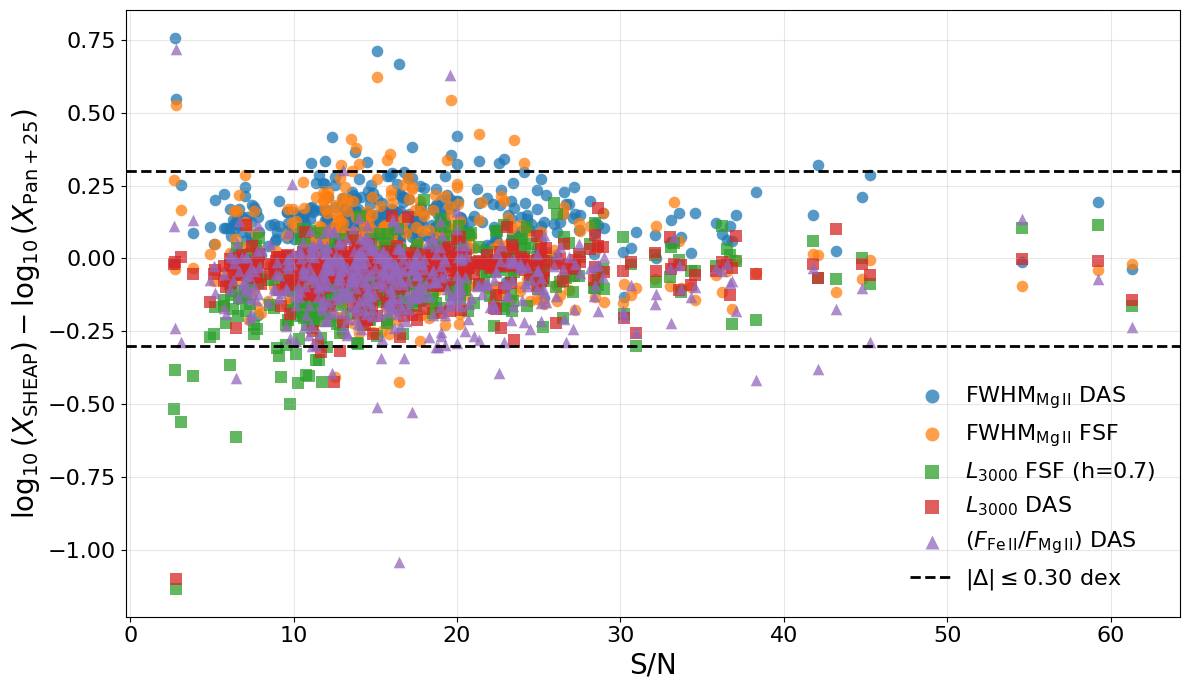

: 

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

#main_key = "Values Pan+25"
labels_p = [r"FWHM$_{\rm Mg\,II}$",r"$L_{3000}$",r"$(F_{\rm Fe\,II}/F_{\rm Mg\,II})$"]
main_key_list = ["DAS values","FSF values",'FSF (h=0.7)',"DAS"]
markers = ["o", "s", "^", "D", "D", "D"]

# --- Font / style knobs ---
fs_label  = 20
fs_ticks  = 16
fs_legend = 16
marker_size = 70
alpha_val = 0.75

# --- Collect exactly-plotted data here ---
plot_data = {}  # plot_data[label] = {"x": x_plotted, "y": y_plotted}

fig, ax = plt.subplots(figsize=(12, 7))

for nn, D in enumerate(dictionaries):
	#res = dd[main_key]["res"]
	X = [val for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	sub_label = [k for k in main_key_list for val in [D.get(k, {}).get("res")] if val is not None]
	s_local = labels_p[nn]
	for ii,res in enumerate(X):
		local_ = sub_label[ii].replace("values","")
		#print(summary_similarity(D[sub_label[ii]], name=f"{s_local} {local_}"))
		x_plot = sheapspectral.snr
		y_plot = res
		plot_data[f"{s_local} {local_}"] = {
		"x": x_plot,
		"y": y_plot,
		"marker": markers[nn],
		#"main_key": main_key,
		}

		ax.scatter(
			x_plot, y_plot,
			marker=markers[nn],
			s=marker_size,
			alpha=alpha_val,
			label=f"{s_local} {local_}",
			linewidths=0.0
		)
	#snr_local = sheapspectral.snr#[mask_local]

	#if len(res) != len(snr_local):
	 #   raise ValueError(f"Length mismatch: res={len(res)} vs snr_local={len(snr_local)}")

	#ok = np.isfinite(snr_local) & np.isfinite(res)

	# these are the ONLY points that go to the scatter


	

ax.axhline(0.3, linestyle="--", linewidth=2,c="k")
ax.axhline(-0.3, linestyle="--", linewidth=2,c="k",label=rf"$|\Delta|\leq {0.3:.2f}\ \mathrm{{dex}}$")

ax.set_xlabel("S/N", fontsize=fs_label)
ax.set_ylabel(r"$\log_{10}(X_{\rm SHEAP}) - \log_{10}(X_{\rm Pan+25})$", fontsize=fs_label)
ax.tick_params(axis="both", which="major", labelsize=fs_ticks)
ax.tick_params(axis="both", which="minor", labelsize=fs_ticks - 2)
ax.grid(True, alpha=0.3)

ax.legend(
	fontsize=fs_legend,
	frameon=False,
	loc="best",
	markerscale=1.2,
	handletextpad=0.5,
	borderpad=0.6
)

plt.tight_layout()
plt.savefig("images/signal_2_noise_vs_res_pan.pdf", dpi=300, format="pdf", bbox_inches="tight")
plt.show()

# --- Save the plotted x/y to pickle ---
os.makedirs("images", exist_ok=True)
pkl_path = "images/signal_2_noise_vs_res_pan.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(plot_data, f, protocol=pickle.HIGHEST_PROTOCOL)

#print(f"Saved plotted x/y to: {pkl_path}")


In [62]:








	
	x = x[np.isfinite(x)]
	frac_within = np.round(D[main_key]["frac_within"],3)*100
	s =labels[nn]
	print(summary_similarity(D[main_key], name=s))
	#print(f"for ,{s} the frac within is {frac_within}, ")
	# ax.hist(
	#     x, bins=edges, density=density,
	#     edgecolor="black", alpha=0.55, label=s
	# )
	ax.hist(
		x,
		bins=edges,
		density=density,
		histtype="stepfilled",
		linewidth=3.0,
		edgecolor="black",
		alpha=0.25,   # lower alpha helps a lot
		label=s,
	)
# zero + band lines ONCE
ax.axvline(0.0, linestyle="--", linewidth=1.0, color="k")
ax.axvline(+band, linestyle="--", linewidth=2.0, color="k")
ax.axvline(-band, linestyle="--", linewidth=2.0, color="k")
s = rf"$\log_{{10}}(X_{{\rm SHEAP}}) - \log_{{10}}(X_{{\rm {compared_xlabel}}})$"
ax.set_xlabel(s,fontsize=FS)

ax.set_ylabel("Density" if density else "Count", fontsize=FS)

# ticks + grid
ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.tick_params(axis="both", which="minor", labelsize=TICK_FS - 2)
ax.grid(axis="y", linestyle="--", alpha=0.35)

# legend entries
handles, labels = ax.get_legend_handles_labels()
band_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
					label=rf"$|\Delta|\leq {band:.2f}\ \mathrm{{dex}}$")
# (optional) show zero separately
# zero_handle = Line2D([], [], linestyle="--", linewidth=2.0, color="k",
#                      label=r"$\Delta=0$")

ax.legend(
	handles + [band_handle],
	labels + [band_handle.get_label()],
	fontsize=LEGEND_FS,
	frameon=True
)
max_val = np.max(np.abs(ax.get_xlim()))
ax.set_xlim(-max_val,max_val)

plt.tight_layout()

NameError: name 'main_key' is not defined

In [ ]:
#[O II] -> 3727
#[Ne III] 3869

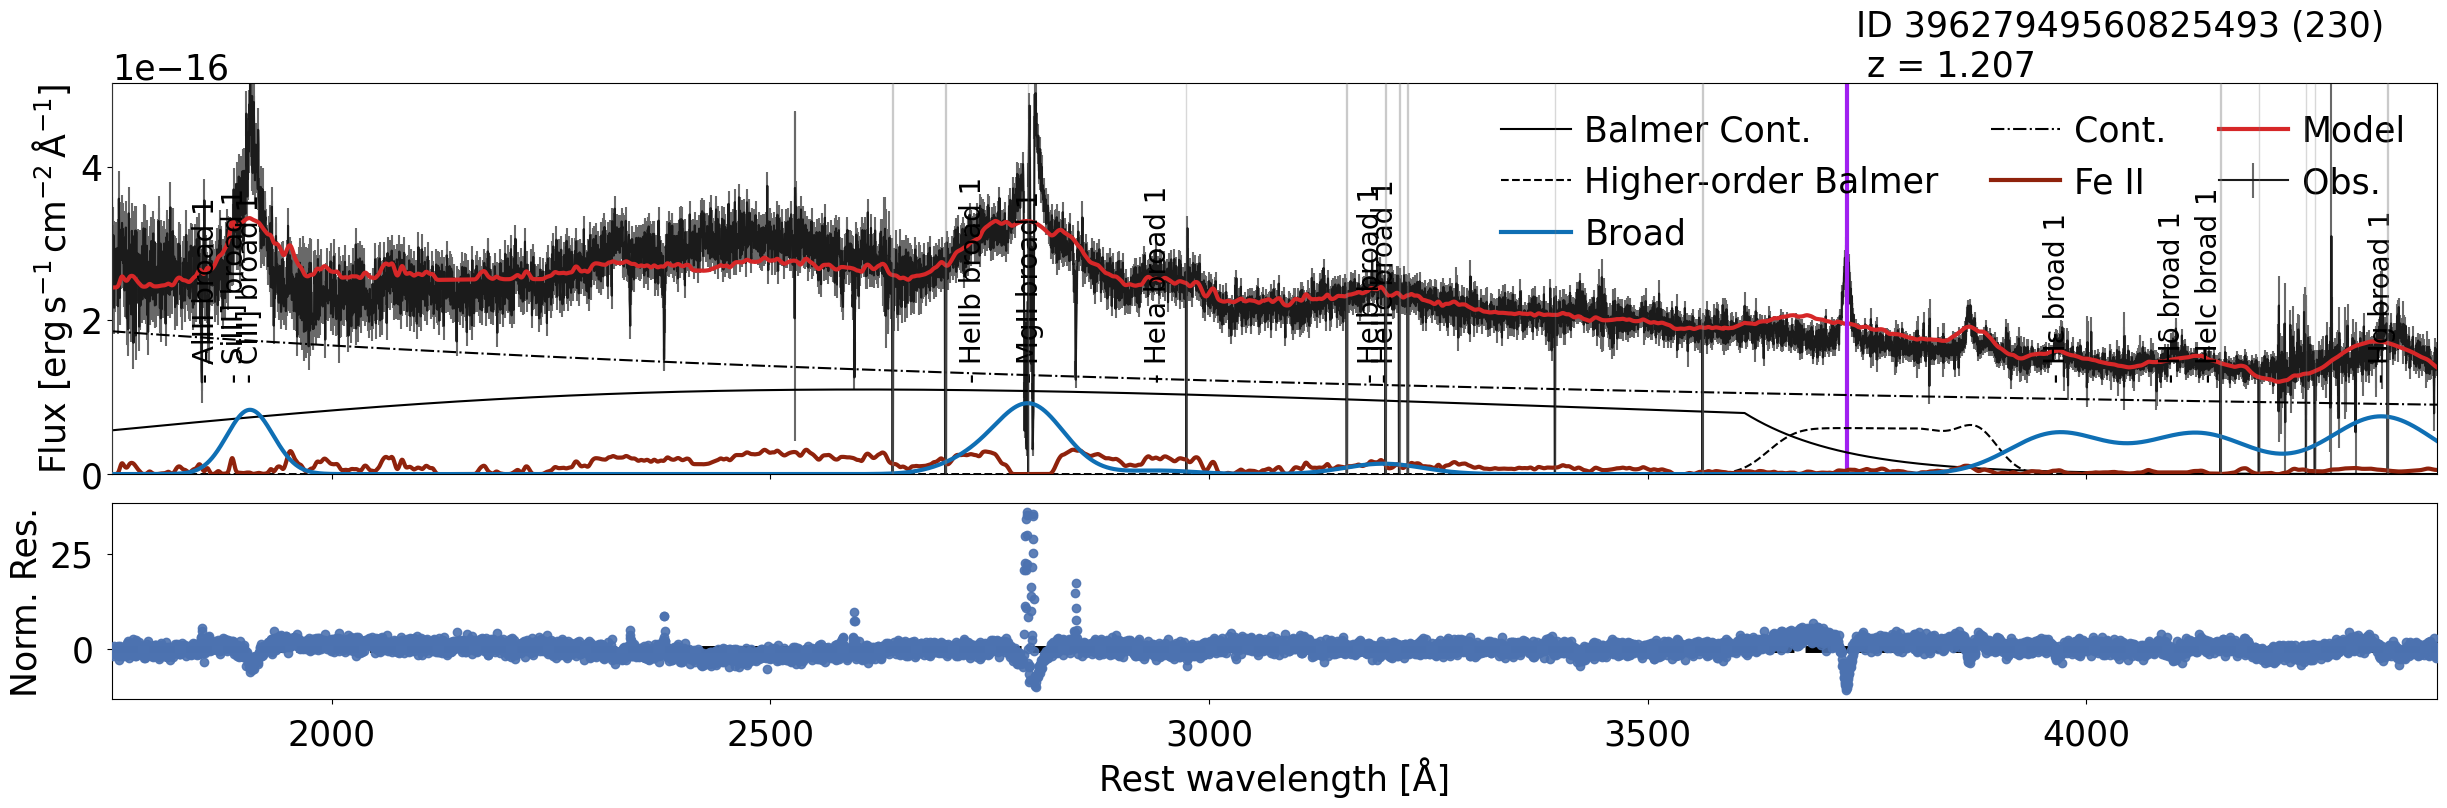

In [ ]:
sheapspectral.modelplot.plot(230,add_xline=3727,add_lines_name=True)

In [ ]:
fe_out["samples"][0]

Array([1.47753633e-14, 1.48458176e-14, 1.56618427e-14, 1.40420749e-14,
       1.54312185e-14, 1.51595538e-14, 1.53717375e-14, 1.47985970e-14,
       1.54628609e-14, 1.50126768e-14, 1.46974289e-14, 1.57393767e-14,
       1.39546642e-14, 1.47323618e-14, 1.47077757e-14, 1.55309532e-14,
       1.51082083e-14, 1.53770141e-14, 1.60661417e-14, 1.53853730e-14,
       1.50669886e-14, 1.45808441e-14, 1.60591166e-14, 1.43825970e-14,
       1.59445931e-14, 1.51828725e-14, 1.57019396e-14, 1.47046244e-14,
       1.60773728e-14, 1.58435742e-14, 1.53489064e-14, 1.48242664e-14,
       1.47898886e-14, 1.59350579e-14, 1.47834977e-14, 1.51786998e-14,
       1.50144509e-14, 1.43003617e-14, 1.54108805e-14, 1.53844163e-14,
       1.56236859e-14, 1.53222891e-14, 1.46952890e-14, 1.55016427e-14,
       1.56505405e-14, 1.47693700e-14, 1.49635399e-14, 1.51148016e-14,
       1.60644506e-14, 1.52769692e-14], dtype=float64)

In [ ]:


# mask = (
#     (df_extra["line"] == "CIV") &
#     (df_extra["SMBHEstimator"] == "VP06_CIV_1350") &
#     (df_extra["quantity"] == "vwidth_kms")
# )

# CIV_FWHM_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
# CIV_FWHM_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
# CIV_FWHM_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)

# mask = (
#     (df_extra["line"] == "CIV") &
#     (df_extra["SMBHEstimator"] == "VP06_CIV_1350") &
#     (df_extra["quantity"] == "Lwave")
# )

# CIV_Lwave_median = df_extra.loc[mask, "median"].to_numpy().flatten().astype(float)
# CIV_Lwave_err_plus = df_extra.loc[mask, "err_plus"].to_numpy().flatten().astype(float)
# CIV_Lwave_err_minus = df_extra.loc[mask, "err_minus"].to_numpy().flatten().astype(float)


/share/cav/data/favila/smbh_mass/sheap/sheap/Utils/Paper.py:112: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


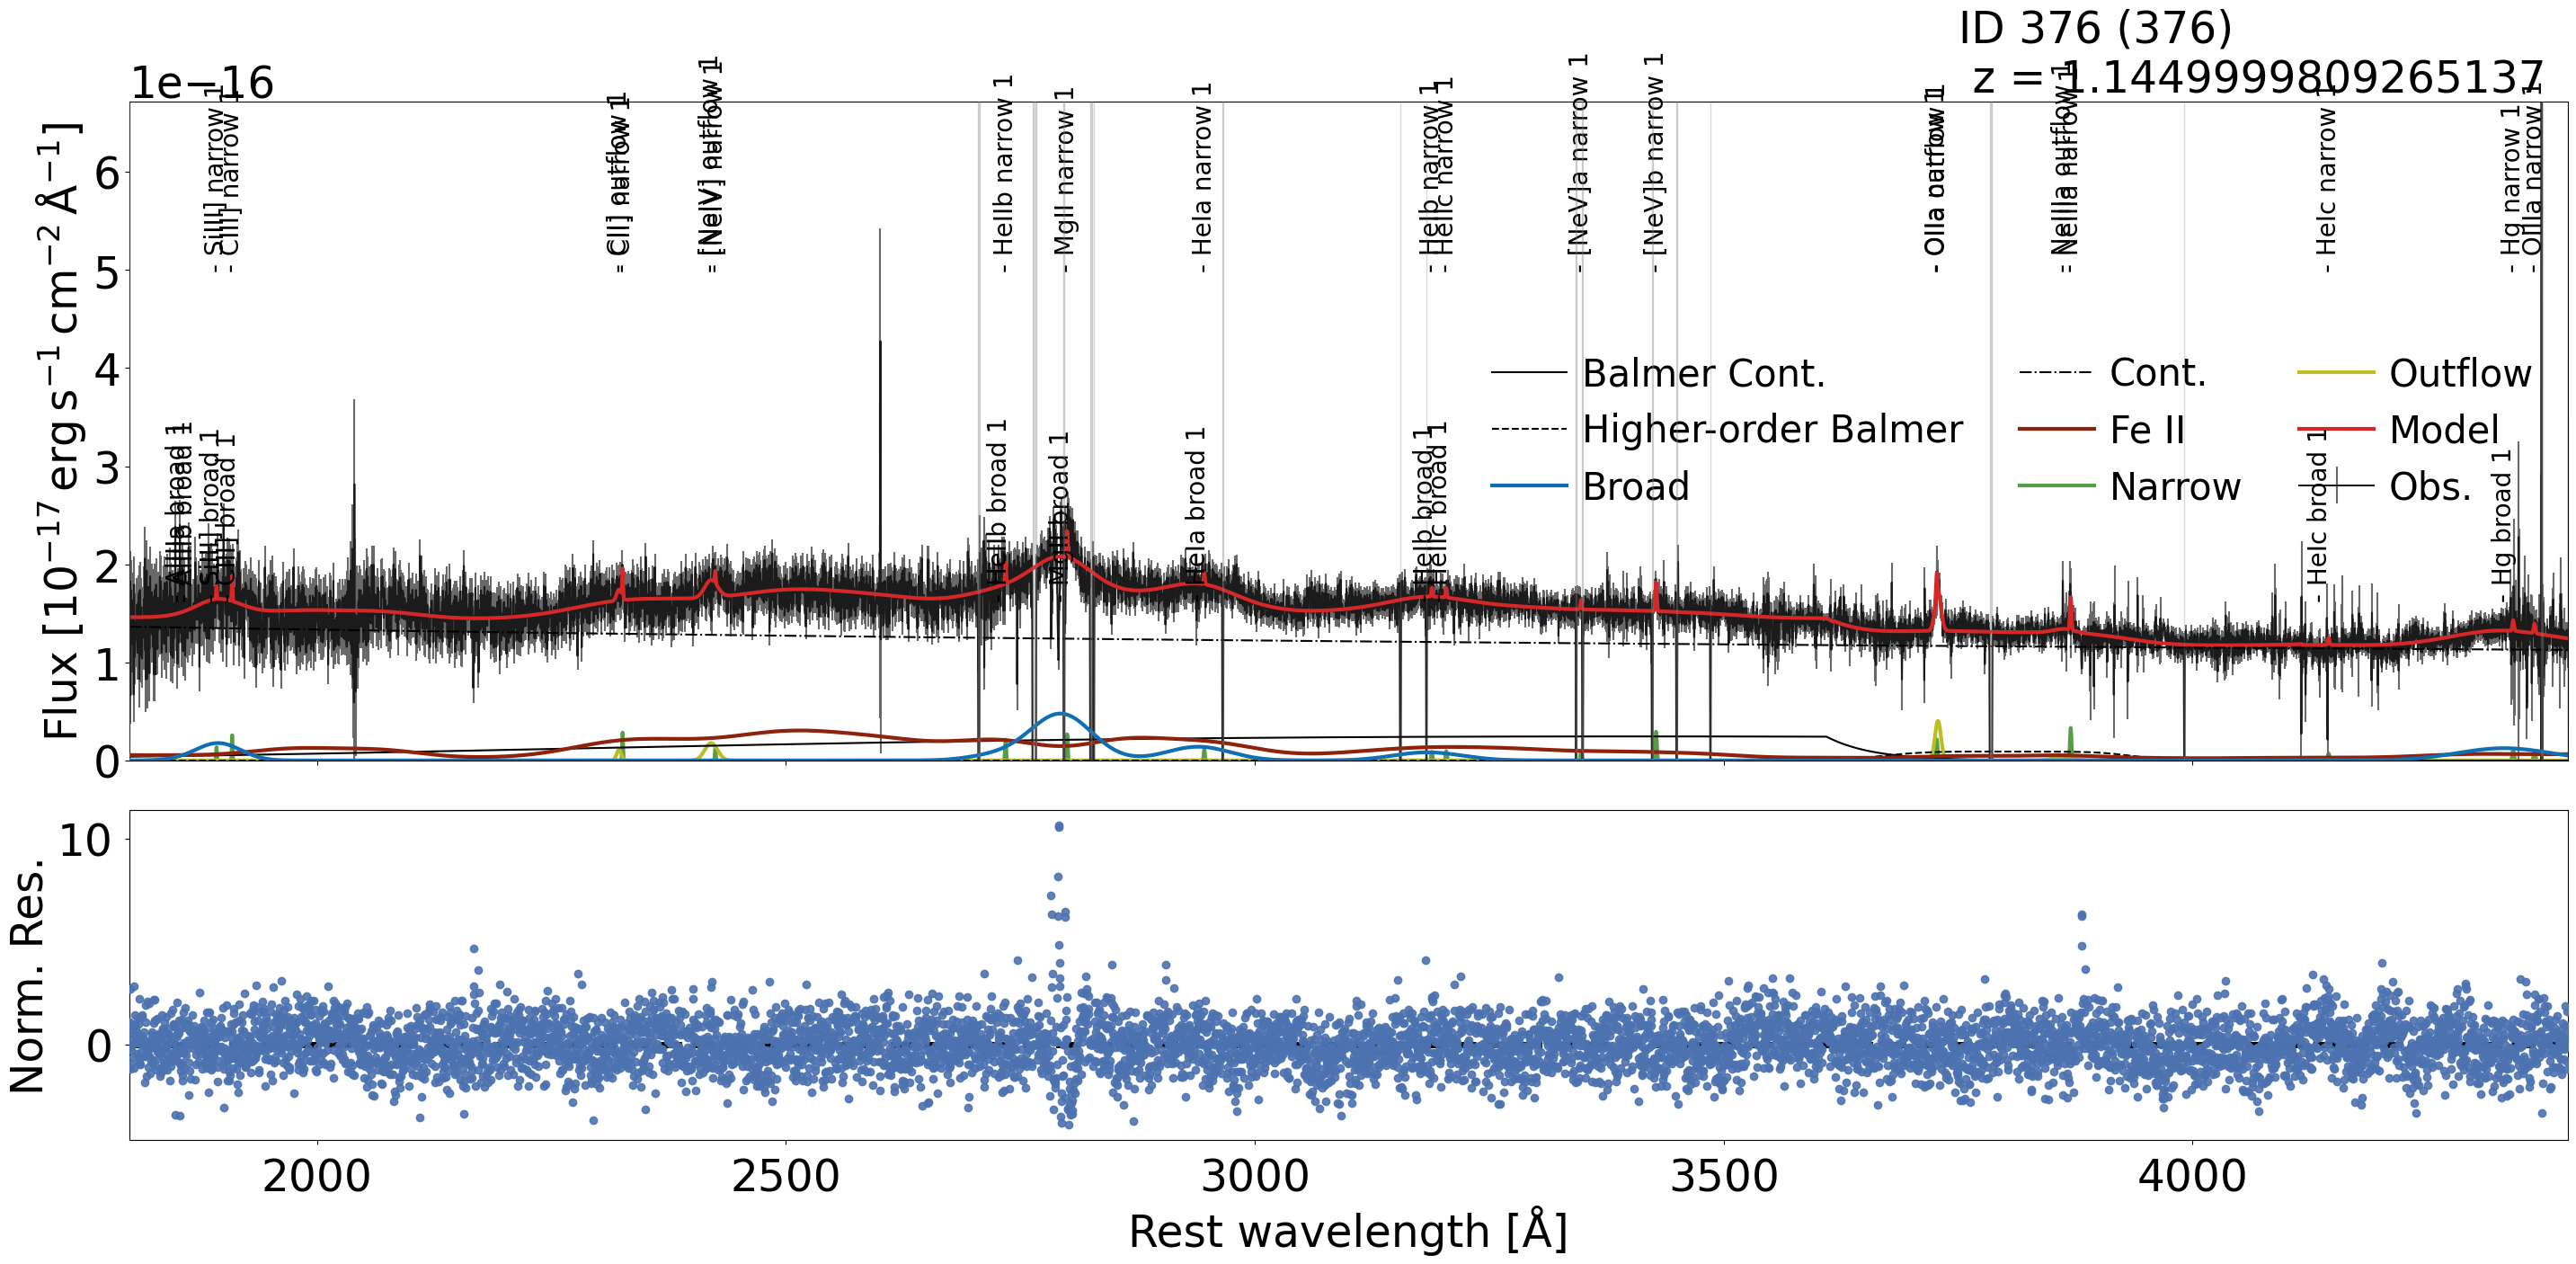

In [ ]:
# sheapspectral.modelplot.plot(376,add_legend=True,add_lines_name=True)

In [ ]:
# chi2_red = np.nan_to_num(sheapspectral.result.chi2_red,1e10)

# # --- Compute fractions in [0,5] ---
# frac_model_0_5 = np.mean((chi2_red >= 0) & (chi2_red <= 5)) * 100

# # --- Define bins ---
# bins = np.linspace(chi2_red.min(),chi2_red.max(), 40)

# # --- Plot ---
# plt.figure(figsize=(10,6))
# plt.hist(chi2_red, bins=bins, alpha=0.6, color="#d62728",
#          label=fr"Model Fe II  (median={np.median(chi2_red):.2f})")


# plt.xlabel(r'Reduced $\chi^2$', fontsize=18)
# plt.ylabel('Number of spectra', fontsize=18)
# plt.legend(fontsize=14, frameon=False)
# plt.tick_params(axis='both', labelsize=14)

# # --- Annotate fractions ---
# plt.text(0.05, 0.92,
#          fr"$0<\chi^2_{{red}}<5$ :$~~{frac_model_0_5:.1f}\%$ (model)",
#          transform=plt.gca().transAxes, fontsize=14, color='k',
#          bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# plt.tight_layout()
# plt.show()


In [ ]:
# # print(f"Model Fe II:     mean={chi2_model:.3f}, median={chi2_model:.3f}, σ={chi2_model:.3f}")
# # print(f"Template Fe II:  mean={chi2_template:.3f}, median={chi2_template:.3f}, σ={chi2_template:.3f}")


# frac_model_0_5 = np.mean((chi2_red >= 0) & (chi2_red <= 2)) * 100

# bins = np.linspace(chi2_red.min(),chi2_red.max(), 100)

# # --- Plot ---
# plt.figure(figsize=(10,6))
# plt.hist(chi2_red, bins=bins, alpha=0.6, color="#d62728",
#          label=fr"Model Fe II  (median={np.median(chi2_red):.2f})")


# plt.xlabel(r'Reduced $\chi^2$', fontsize=18)
# plt.ylabel('Number of spectra', fontsize=18)
# plt.legend(fontsize=14, frameon=False)
# plt.tick_params(axis='both', labelsize=14)
# plt.xlim(0,30)
# plt.text(0.5, 0.5,
#          fr"$0<\chi^2_{{\mathrm{{red}}}}<2$:" "\n"
#     fr"  {frac_model_0_5:.1f}%",
#          transform=plt.gca().transAxes, fontsize=14, color='k',)

# plt.tight_layout()
# plt.show()

In [ ]:
#  'REDSHIFT',
#        'RMAG', 'EW_DAS', 'EW_DAS_ERR', 'FWHM_DAS', 'FWHM_DAS_ERR', 'RFE_DAS',
#        'RFE_DAS_ERR', 'L3000_DAS', 'L3000_DAS_ERR', 'LOGMASS_DAS_PAN25',
#        'LOGMASS_DAS_PAN25_ERR', 'LOGMASS_DAS_VO09', 'LOGMASS_DAS_VO09_ERR',
#        'LOGMASS_DAS_SHEN11', 'LOGMASS_DAS_SHEN11_ERR', 'LOGMASS_DAS_LE20',
#        'LOGMASS_DAS_LE20_ERR', 'LOGMASS_DAS_YU23', 'LOGMASS_DAS_YU23_ERR',
#        'L3000_FSF', 'FWHM_FSF', 'LOGMASS_FSF_VO09', 'path'],

In [ ]:
# sheapspectral.result.posterior[1]["0"].keys(

In [ ]:
sheapspectral.result.posterior[1]["0"]["extra_basic_params"]["MgII"]

{'VO09_MgII_3000': {'method': 'continuum',
  'wavelength': 3000,
  'vwidth_def': 'fwhm',
  'vwidth_kms': {'median': array(5394.58933282), 'error': array(0.)},
  'log10_smbh': {'median': array(8.72634569), 'error': array(0.)},
  'Lwave': {'median': array(6.12148319e+45), 'error': array(0.)},
  'Lbol': {'median': array(3.15256384e+46), 'error': array(0.)},
  'Ledd': {'median': array(6.70990295e+46), 'error': array(0.)},
  'mdot_msun_per_year': {'median': array(5.56682294), 'error': array(0.)},
  'component': array([1])},
 'Shen11_MgII_3000': {'method': 'continuum',
  'wavelength': 3000,
  'vwidth_def': 'fwhm',
  'vwidth_kms': {'median': array(5394.58933282), 'error': array(0.)},
  'log10_smbh': {'median': array(8.82076849), 'error': array(0.)},
  'Lwave': {'median': array(6.12148319e+45), 'error': array(0.)},
  'Lbol': {'median': array(3.15256384e+46), 'error': array(0.)},
  'Ledd': {'median': array(8.33948128e+46), 'error': array(0.)},
  'mdot_msun_per_year': {'median': array(5.56682294

: 

In [ ]:
# #'extra_combine_params', 'extra_combined_pyqso'
# MgII_FWHM = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["MR16_global_MgII_L3000_FWHM"]["vwidth_kms"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# MgII_L300 = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["MR16_global_MgII_L3000_FWHM"]["Lwave"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values

# VO09_MgII_3000 =  pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["VO09_MgII_3000"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# Shen11_MgII_3000 = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["Shen11_MgII_3000"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# Le20_MgII_3000_FWHM = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["Le20_MgII_3000_FWHM"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# Yu23_MgII_3000 = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["Yu23_MgII_3000"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values
# Pan25_MgII_3000_RFe = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["Pan25_MgII_3000_RFe"]["log10_smbh"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values

# #R_Fe = pd.DataFrame([{"name": key,**values["extra_basic_params"]["MgII"]["extras"]["R_Fe"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values

# #R_Fe = pd.DataFrame([{"name": key,**values["combined_params"]["MgII"]["extras"]["R_Fe"]} for key, values in sheapspectral.result.posterior[1].items()])["median"].astype(float).values


# MgII_DAS = base_panda.FWHM_DAS.values
# MgII_FSF = base_panda.FWHM_FSF.values

# MgII_L300_DAS = base_panda.L3000_DAS.values*1e44
# MgII_L300_FSF = base_panda.L3000_FSF.values*1e44 

# RFE_DAS = base_panda.RFE_DAS.values

# LOGMASS_DAS_VO09 = base_panda.LOGMASS_DAS_VO09.values
# LOGMASS_DAS_SHEN11 = base_panda.LOGMASS_DAS_SHEN11.values
# LOGMASS_DAS_LE20 = base_panda.LOGMASS_DAS_LE20.values
# LOGMASS_DAS_YU23 = base_panda.LOGMASS_DAS_YU23.values
# LOGMASS_DAS_PAN25 = base_panda.LOGMASS_DAS_PAN25.values

# LOGMASS_FSF_VO09 = base_panda.LOGMASS_FSF_VO09.values


# df_mgii = pd.DataFrame({
#     # identifiers
#     "name": sheapspectral.names,

#     # SHEAP / template-style measurements
#     "MgII_FWHM_sheap": MgII_FWHM,
#     "MgII_L3000_sheap": MgII_L300,

#     # SHEAP-based BH masses from different calibrations
#     "logMBH_VO09_sheap": VO09_MgII_3000,
#     "logMBH_Shen11_sheap": Shen11_MgII_3000,
#     "logMBH_Le20_FWHM_sheap": Le20_MgII_3000_FWHM,
#     "logMBH_Yu23_sheap": Yu23_MgII_3000,
#     "logMBH_Pan25_RFe_sheap": Pan25_MgII_3000_RFe,

#     # DAS/FSF line widths
#     "MgII_FWHM_DAS": MgII_DAS,
#     "MgII_FWHM_FSF": MgII_FSF,

#     # DAS/FSF luminosities
#     "MgII_L3000_DAS": MgII_L300_DAS,
#     "MgII_L3000_FSF": MgII_L300_FSF,

#     # R_Fe and DAS/FSF BH masses
#     "RFe_DAS": RFE_DAS,
#     "logMBH_DAS_VO09": LOGMASS_DAS_VO09,
#     "logMBH_DAS_Shen11": LOGMASS_DAS_SHEN11,
#     "logMBH_DAS_Le20": LOGMASS_DAS_LE20,
#     "logMBH_DAS_Yu23": LOGMASS_DAS_YU23,
#     "logMBH_DAS_Pan25": LOGMASS_DAS_PAN25,
#     "logMBH_FSF_VO09": LOGMASS_FSF_VO09,
# })


# # Save to CSV
# #df_mgii.to_csv("../CSVs/MgII_comparison_sheap_DAS_FSF.csv", index=False)


# # Save full table



In [ ]:
# #plt.hist(RFE_DAS)
# plt.hist(R_Fe)
# #plt.xlim(0,5)


In [ ]:
# R_Fe

In [ ]:
# base_panda.RFE_DAS

In [ ]:
# R_Fe

In [ ]:
# Pan25_MgII_3000_RFe

In [ ]:
10**3.25

1778.2794100389228

In [ ]:
MgII_FSF[12],MgII_DAS[12]

(np.float64(2376.99), np.float64(1560.04))

In [ ]:
MgII_FWHM[12]

np.float64(5326.809094752667)

In [ ]:
10**3.220115

1660.0264197342867

In [ ]:
# pd.set_option("display.max_rows", None) 
# sheapspectral.result_panda(456)

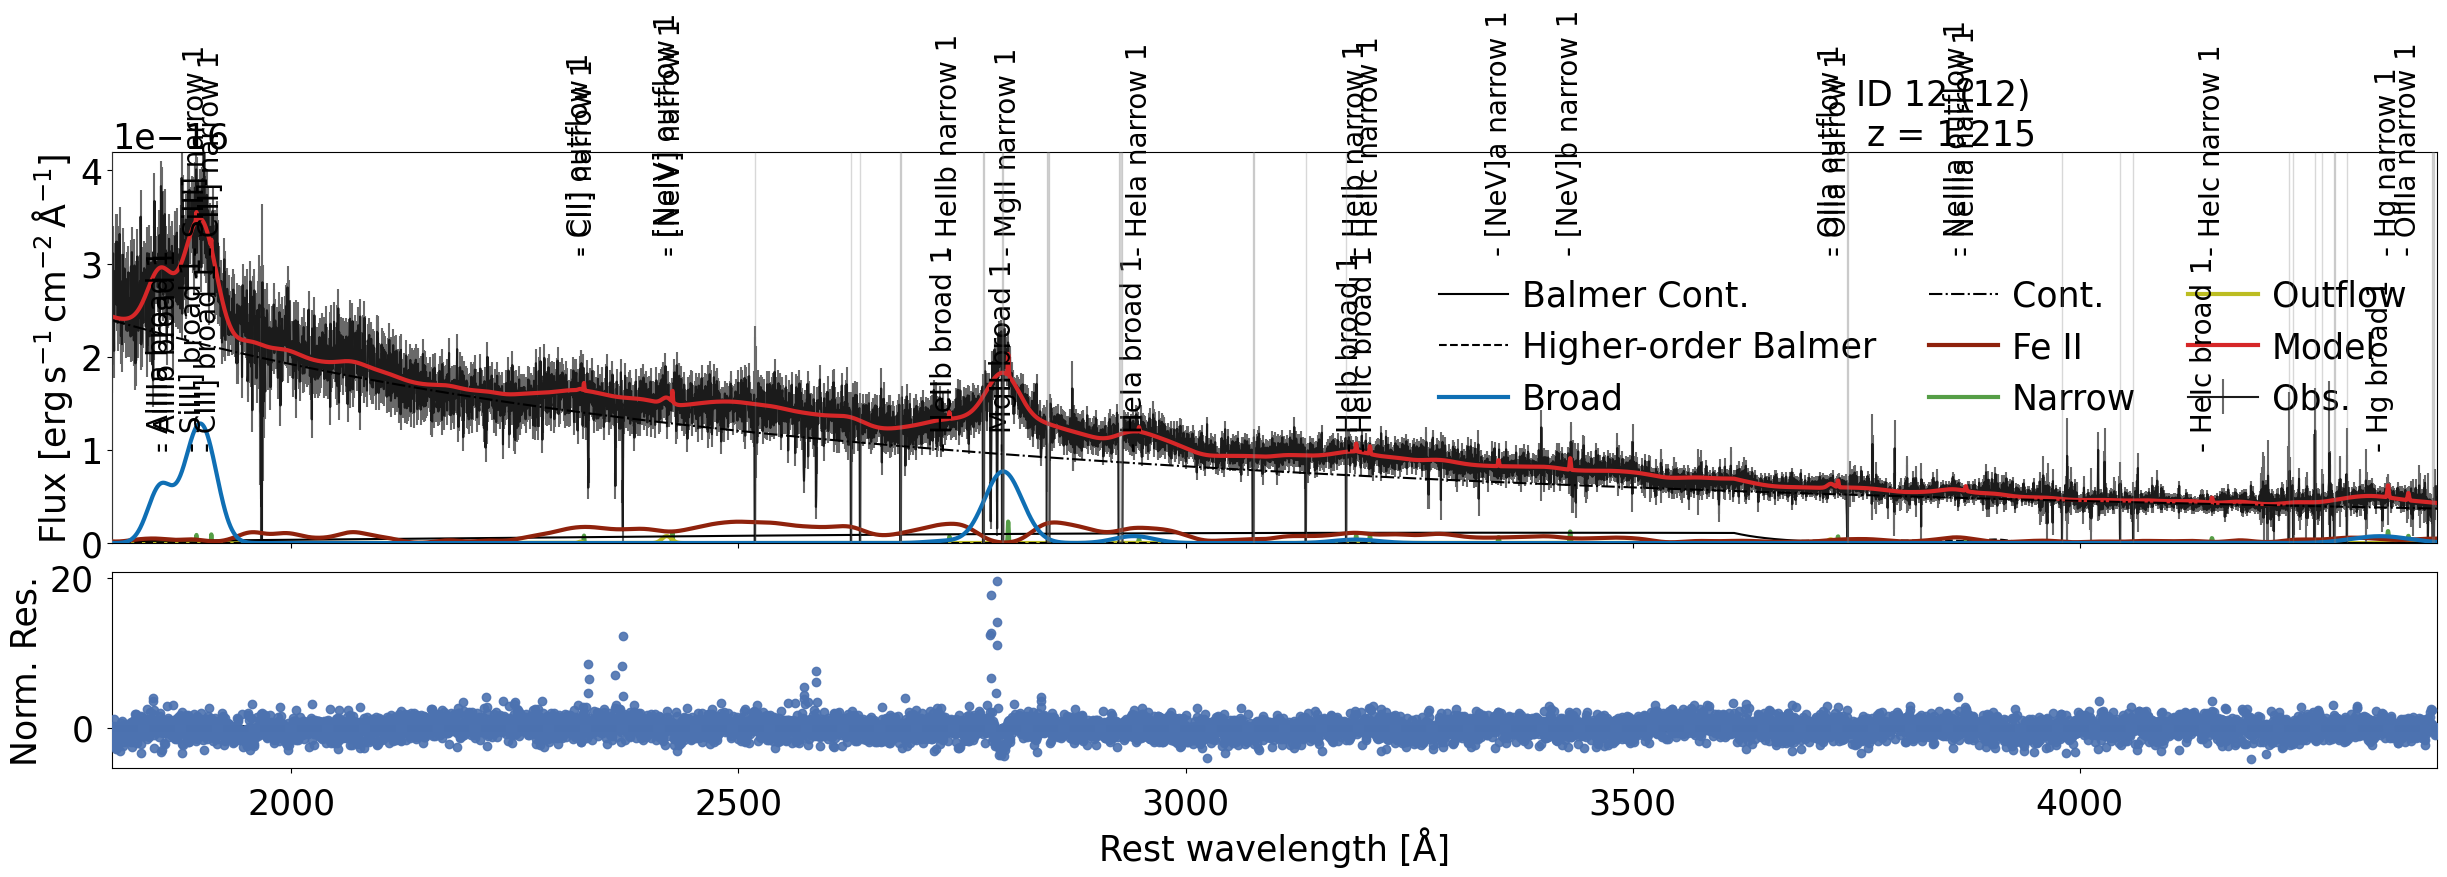

In [24]:
sheapspectral.modelplot.plot(12,add_legend=True,add_lines_name=True)